In [50]:
# Importing libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [26]:
# Loading the dataset
df = pd.read_csv("insurance_fraud_data.csv")

In [27]:
# First 5 rows
df.head(5)

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy deductible,annual premium,days open,form defects,fraud reported
0,414724,39,M,1,73,58612.8,1,0,Own,50048,...,Large,24360.59273,silver,26633.27819,5196.552552,1000,1406.91,8.641800,5,N
1,269568,33,M,1,72,35936.0,0,1,Own,50006,...,Medium,23457.35282,black,26707.46021,7957.267641,2000,1415.74,10.009761,5,Y
2,974592,31,M,1,76,84940.8,1,1,Own,15021,...,Medium,19752.42523,gray,15279.38583,3014.110884,1000,1199.44,8.264032,3,N
3,995328,53,F,1,93,73526.4,0,1,Own,85027,...,Medium,32910.34224,red,20909.27772,5671.599025,500,708.64,9.235943,4,N
4,1140480,41,M,1,87,59403.2,1,0,Own,80046,...,Medium,28570.37675,red,34493.97997,4064.569489,1000,1187.96,10.259629,2,N


In [28]:
# Last 5 rows
df.tail(5)

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy deductible,annual premium,days open,form defects,fraud reported
11997,621727488,34,M,1,88,66505.6,1,1,Rent,20134,...,Large,24134.334750,red,34516.53474,6639.049156,1000,1622.67,12.449888,3,N
11998,621810432,65,F,1,97,23315.2,1,0,Rent,20134,...,Compact,57417.739270,gray,26718.21104,3382.4126,500,1055.60,9.730108,6,Y
11999,621872640,64,F,1,87,66505.6,0,1,Own,20142,...,Large,20231.723630,other,27015.87981,7475.901535,2000,1155.97,8.386094,2,N
12000,621914112,34,F,1,70,76409.6,1,0,Own,20109,...,Compact,21900.031920,black,16122.91954,3838.951645,1000,1726.91,10.314865,5,N
12001,621955584,45,M,1,61,70915.2,1,0,Rent,15044,...,Medium,8291.858346,red,26825.84418,5236.564274,500,1232.57,9.116981,4,N


In [29]:
# Checking missing value
df.isnull().sum()

,0
claim_number,0
age_of_driver,0
gender,0
marital_status,0
safety_rating,0
annual_income,0
high_education,0
address_change,0
property_status,0
zip_code,0


In [34]:
# Remove rows with missing values
df.dropna(inplace=True)

In [36]:
# Checking for missing values
df.isnull().sum()

,0
claim_number,0
age_of_driver,0
gender,0
marital_status,0
safety_rating,0
annual_income,0
high_education,0
address_change,0
property_status,0
zip_code,0


In [37]:
# Dropping claim_date column as it is not useful
df.drop("claim_date", axis=1, inplace=True)

In [39]:
# Encode categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [40]:
# Seperating features and target
X = df.drop("fraud reported", axis=1)
y = df["fraud reported"]

In [42]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
# Make predictions
prediction = model.predict(X_test)

In [47]:
# Check accuracy
accuracy = accuracy_score(y_test, prediction)
print("Accuracy:", accuracy)

Accuracy: 0.7840766986244269


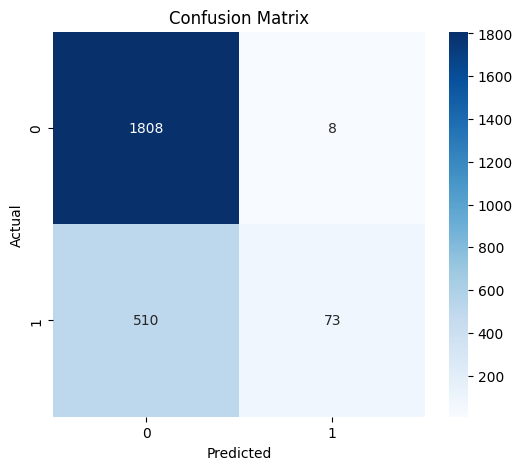

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save image
plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

In [51]:
# Classification matrix
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.78      1.00      0.87      1816
           1       0.90      0.13      0.22       583

    accuracy                           0.78      2399
   macro avg       0.84      0.56      0.55      2399
weighted avg       0.81      0.78      0.72      2399

